In [1]:
# %pip install git+https://github.com/Mishne-Lab/pyRATS
# if not already installed on the system:
# %pip install pandas imageio seaborn matplotlib

import sys
sys.path.insert(0, '../src/')
sys.path.insert(0, '../')

from pyRATS import rats
import os
import numpy as np
import scipy.io as spio
np.random.seed(42)

In [2]:
def de_mean(inputmat):
    #bas
    outputmat=np.zeros_like(inputmat)
    for i in range(len(inputmat)):
        outputmat[i,:]=(inputmat[i,:]-np.mean(inputmat[i,:]))
    return outputmat


# Path to where the data folder is extracted
base_dir = r"../data"

experiment = 'IsoExample1'   # 'IsoExample1', 'IsoExample2', or 'IsoExample3'
PCA        = True
PCs        = 6
dim        = 3               # target embedding dimension (d) for RATS

# Derived paths
data_dir    = os.path.join(base_dir, "HPC_Manifold_Project") + os.sep
results_dir = os.path.join(base_dir, "Results") + os.sep
saveloc     = os.path.join(results_dir, experiment)

if not os.path.isdir(saveloc):
    os.makedirs(saveloc)

# LOAD DATA
data = spio.loadmat(data_dir + experiment + '.mat')

X_train      = data['X_train']
new_location = data['new_location']
thisvelocity = data['thisvelocity'].flatten()
velocity = data['velocity']
locColor     = data['locColor']
newY         = data['newY']
bestIsoIdx   = int(data['bestIsoIdx'][0, 0])
labelsmat    = X_train[:, 0]

print(f"Loaded {experiment}: X_train shape = {X_train.shape}")


# ============================================================================
# PCA preprocessing
# ============================================================================
if PCA:
    standRates = de_mean(X_train.T)
    covariance_mat = np.cov(standRates)
    eigenvalues, eigenvectors = np.linalg.eig(covariance_mat)

    eigenvalues_indices = np.argsort(eigenvalues)
    sorted_eigenvalues  = np.flip(eigenvalues[eigenvalues_indices])
    components          = eigenvectors[:, np.flip(eigenvalues_indices)]
    projection          = [components[:, i] @ X_train.T for i in range(PCs)]

    X_input    = np.transpose(np.vstack(projection))
    pca_suffix = f"PCA_{PCs}PCs"
    print(f"PCA reduced X_train to shape {X_input.shape}")
else:
    X_input    = X_train
    pca_suffix = ""

X_input = np.array(X_input)


Loaded IsoExample1: X_train shape = (7334, 104)
PCA reduced X_train to shape (7334, 6)


In [3]:
k=30
eta_min=3

if not hasattr(np, 'object'):
    np.object = object  # patch deprecated alias

model = rats.RATS(
    n_components=dim,
    kernel='rbf',
    postprocess=True,
    n_neighbors=k,
    min_cluster_size=eta_min, cost_function='alignment',
    tear=False, n_iter=1,
    global_init_algo_name='spectral', 
    repel_by=1, n_repel=100, repel_decay=0.9, 
    alpha=0.1
)
X_rats_org = model.fit_transform(X=X_input)
idx        = f'eta{eta_min}k{k}'
result     = (idx, {'X': X_rats_org, 'hyp1': eta_min, 'hyp2': k})

/var/folders/bh/hyvnvd611gq4n0_zb8m0gm6r0000gp/T/ipykernel_94554/1470044022.py:4: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, 'object'):


In [4]:
# %matplotlib widget

import matplotlib.pyplot as plt
import colorsys

In [5]:
rgbloccolor = []
for i, j, k in locColor:
    rgbloccolor.append(colorsys.hsv_to_rgb(i, j, k))

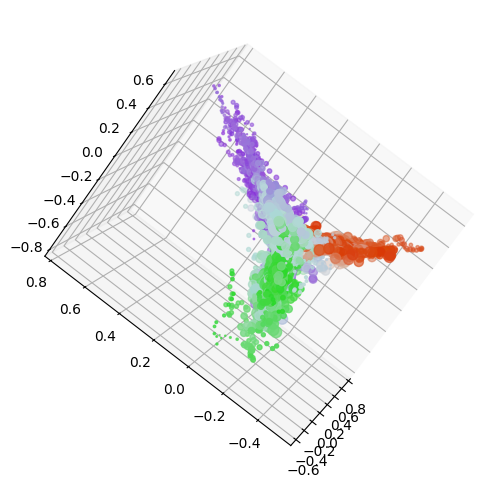

In [6]:
res = X_rats_org
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    res[:-1, 0], res[:-1, 1], res[:-1, 2],
    c = rgbloccolor,
    s=thisvelocity,
)

ax.view_init(elev=15, azim=-175, roll=-36)

plt.show()